El objetivo de este proyecto es hacer un anñalisis de reseñas que usuarios estuvieron haciendo a videojuegos dependiendo tanto de la plataforma como del género del videojuego, estos datos son del año 2016.

El objetivo de este análisis es determinar si el videojuego tiene éxito o no.

In [4]:
#Inicialización de los datos, carga de las librerías que se van a necesitar
from scipy import stats as st
from scipy.stats import ttest_ind
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Antes de hacer la evaluación, quise hacer una visualización sobre las diferentes columnas del dataset, esto es para hacer un filtrado en caso de que tengamos tanto valores duplicados, como valores nulos que puedan perjudicar este análisis.

In [6]:
#Carga de los datos del dataframe
df=pd.read_csv("DataSet.csv")
#Visualización general del dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


En esta visualización, podemos notar como tenemos algunas situaciones:
1) Year_of_Release: Esta columna debería ser de tipo entero.
2) Genre: Tiene algunos valores nulos o faltantes 
3) Critic_Score: Tiene muchísimos valores nulos o faltantes 
4) User_Score: Lo recomendable es que sea de tipo float, para medir correctamente la calificación
5) Rating: Tiene valores nulos o faltantes

En este proyecto, yo propuse las siguientes soluciones:
1) Reemplazar los valores de las columnas a minúsculas
2) Convertir tanto las columnas de user_score a flotante y la columna year_of_release a entero
   
Como justificación, reemplazamos el valor TBD puesto que aun no está disponible, por lo que mejor lo cambiamos por NaN para su analisis estadístico
Aunque los años deberían ser enteros, había valores ausentes, por lo que se convierte a Int64 para permitir los nulos y garantizar que los años sean tratados correctamente como números.

3) Realizar un trataimento de valores ausentes

Como justificación se toman las siguientes consideraciones
- Para las siguientes columnas, considero que no deben rellenarse:
- user_score: tbd significa que no se ha determinado el valor, por lo que no hay info confiable, rellenarlo para calcular la media podría ser engañoso
- critic_score: No todos los juegos son evaluados por los críticos, por lo que podría distorsionar la media si rellenamos sería engañoso
- rating: Muchos juegos indie no son sometidos al rating de ESRB, por lo que podemos analizarlas aparte
- Para la columna de year_of_release podríamos eliminar filas con años ausentes puesto que nos ayudara a agrupar datos y filtrar años del 2016 o antes 

In [9]:
#Preparación de datos
# Reemplazo de los nombres de las columnas a minusculas
df.columns=df.columns.str.lower()
#print(df.columns) ##Valoracion si se cambiaron los nombres a minusculas

In [10]:
# Conversion de datos necesarios
df["user_score"] = pd.to_numeric(df["user_score"].replace("tbd", np.nan), errors="coerce") # Reemplazo 'tbd' en user_score por NaN y conversión a float
df["year_of_release"] = pd.to_numeric(df["year_of_release"],errors="coerce").astype("Int64")# Reemplazo a entero, permite Nan

In [11]:
#Tratamiento de valores ausentes
print(df.isna().sum()) #Previsualizacion para vizualizar los valores ausentes
df.dropna(subset=["year_of_release"], inplace=True)# Eliminamos filas sin año de lanzamiento (clave para análisis temporal)

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


Una vez realizados los cambios pertinentes, se procede a realizar el cálculo de las ventas totales con el fin de hacer la relación entre críticas y ventas

In [12]:
#Cálculo de las ventas totales
df["total_sales"]=df[["na_sales", "eu_sales", "jp_sales", "other_sales"]].sum(axis=1)#Creacion de la columna nueva que incluye las ventas
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16446 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16446 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16444 non-null  object 
 4   na_sales         16446 non-null  float64
 5   eu_sales         16446 non-null  float64
 6   jp_sales         16446 non-null  float64
 7   other_sales      16446 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           9768 non-null   object 
 11  total_sales      16446 non-null  float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 1.6+ MB


In [13]:
##Contabilizasción de juegos lanzados por año
lanzamientos_anuales=df["year_of_release"].value_counts().sort_index() # Contar cuántos juegos fueron lanzados por año
print(lanzamientos_anuales)##Muestra de los valores de 1980 hasta el 2016

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: count, dtype: Int64


Realizamos una gráfica de barras sobre las ventas para tener una mejor visualización

<function matplotlib.pyplot.show(close=None, block=None)>

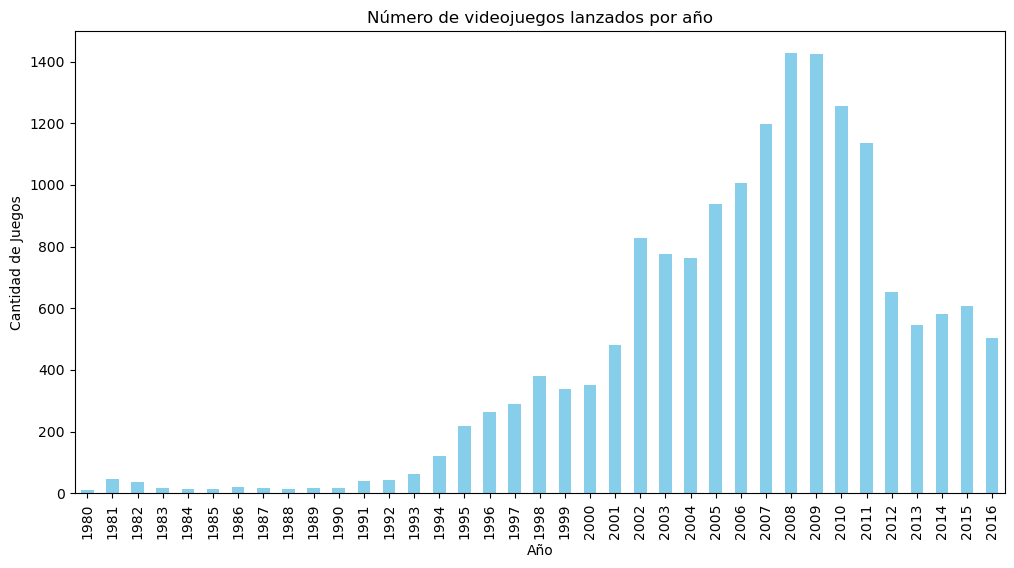

In [14]:
#Visualización mediante gráfico de barras (Es el más acertivo para esta visualización)
lanzamientos_anuales_df=lanzamientos_anuales.reset_index() #Creación de un nuevo dataframe
lanzamientos_anuales_df.columns=["year_of_release","total_games"]
lanzamientos_anuales_df.plot(
    x="year_of_release",
    y="total_games",
    kind="bar",
    title="Número de videojuegos lanzados por año",
    xlabel="Año",
    ylabel="Cantidad de Juegos",
    legend=False,
    color="skyblue",
    figsize=(12,6)
)

plt.show

CONCLUSIONES SOBRE LAS VENTAS DE VIDEOJUEGOS ANUALES
- Podría opinar que el el pico en ventas de los juegos empieza a partir del 2002, esto a pesar que en los 2 años siguientes las ventas no subieron tanto,esto puede darse debido a los lanzamientos de las consolas de esas épocas.
- El boom de las ventas sin duda se da a partir del 2005, ya que la tendencia sibe hasta el año 2009, de nuevo por lanzamientos de consolas más modernas

De igual forma, realicé una contabilización de venta por plataforma con el objetivo de hacer comparativas y ver como influye en la venta de los juegos y cuales son las plataformas con mayores ventas

In [16]:
#Contabilización de venta por plataforma
ventas_plataforma=df.groupby("platform")["total_sales"].sum().sort_values(ascending=False)
print(ventas_plataforma.head(10))##Muestra de ventas por plataforma

platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
Name: total_sales, dtype: float64


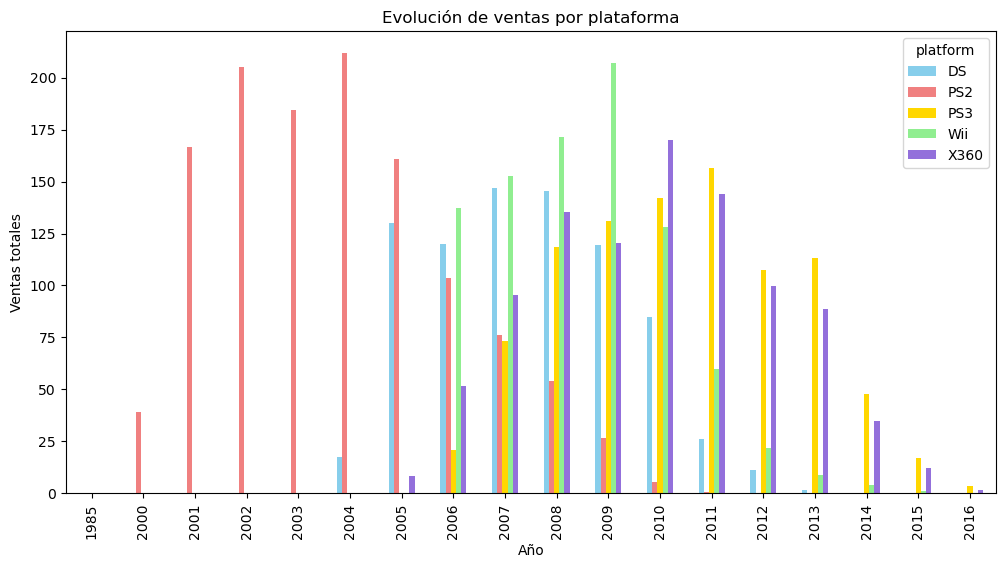

In [17]:
# Filtrar solo las plataformas con mayores ventas
top_plataformas=ventas_plataforma.head(5).index  # Seleccionamos las 5 más vendidas
ventas_por_año = df.groupby(["year_of_release", "platform"])["total_sales"].sum().reset_index()
ventas_top_plataformas=ventas_por_año[ventas_por_año["platform"].isin(top_plataformas)]
ventas_top_plataformas_df=ventas_top_plataformas.pivot(index="year_of_release", columns="platform", values="total_sales").reset_index() # Convertimos los datos de ventas por año y plataforma en un DataFrame
ventas_top_plataformas_df.plot(
    x="year_of_release",
    kind="bar",
    title="Evolución de ventas por plataforma",
    xlabel="Año",
    ylabel="Ventas totales",
    legend=True,
    figsize=(12, 6),
    color=["skyblue", "lightcoral", "gold", "lightgreen", "mediumpurple"]
)

plt.show()

In [18]:
# Identificar el primer y último año con ventas de cada plataforma
vida_plataforma = df.groupby("platform")["year_of_release"].agg(["min", "max"])
print(vida_plataforma)

           min   max
platform            
2600      1980  1989
3DO       1994  1995
3DS       2011  2016
DC        1998  2008
DS        1985  2013
GB        1988  2001
GBA       2000  2007
GC        2001  2007
GEN       1990  1994
GG        1992  1992
N64       1996  2002
NES       1983  1994
NG        1993  1996
PC        1985  2016
PCFX      1996  1996
PS        1994  2003
PS2       2000  2011
PS3       2006  2016
PS4       2013  2016
PSP       2004  2015
PSV       2011  2016
SAT       1994  1999
SCD       1993  1994
SNES      1990  1999
TG16      1995  1995
WS        1999  2001
Wii       2006  2016
WiiU      2012  2016
X360      2005  2016
XB        2000  2008
XOne      2013  2016


CONCLUSIONES:
1) Algunas plataformas dominan el mercado por varios años, mientras que otras tienen ciclos de vida más cortos, esto puede ser debido a la recepción del publico hacia las consolas.
2) Se pueden observar las tendencias de plataformas que dejaron de tener ventas y cuándo ocurrió su declive, esto debido a que el tiempo de vida de la consola pasa a su fin.
3) Evaluar cuánto tiempo tarda una nueva plataforma en ganar tracción y cuándo comienzan a desaparecer otras.

Ahora, procedemos a realizar el filtrado de datos que son mas relevantes para el 2017 utilizando al año 2016

In [19]:
#Filtrado de datos relevantes para 2017, se trabajaran con datos del 2016 y se descartarán años anteriores
df_2016 = df[df["year_of_release"]==2016].copy()
print(df_2016.info())
print()
# Calcular ventas totales por plataforma
ventas_por_plataforma_2016 = df_2016.groupby("platform")["total_sales"].sum().sort_values(ascending=False)
print(ventas_por_plataforma_2016.head(10))

<class 'pandas.core.frame.DataFrame'>
Index: 502 entries, 94 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             502 non-null    object 
 1   platform         502 non-null    object 
 2   year_of_release  502 non-null    Int64  
 3   genre            502 non-null    object 
 4   na_sales         502 non-null    float64
 5   eu_sales         502 non-null    float64
 6   jp_sales         502 non-null    float64
 7   other_sales      502 non-null    float64
 8   critic_score     232 non-null    float64
 9   user_score       262 non-null    float64
 10  rating           280 non-null    object 
 11  total_sales      502 non-null    float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 51.5+ KB
None

platform
PS4     69.25
XOne    26.15
3DS     15.14
PC       5.25
WiiU     4.60
PSV      4.25
PS3      3.60
X360     1.52
Wii      0.18
Name: total_sales, dtype: float64


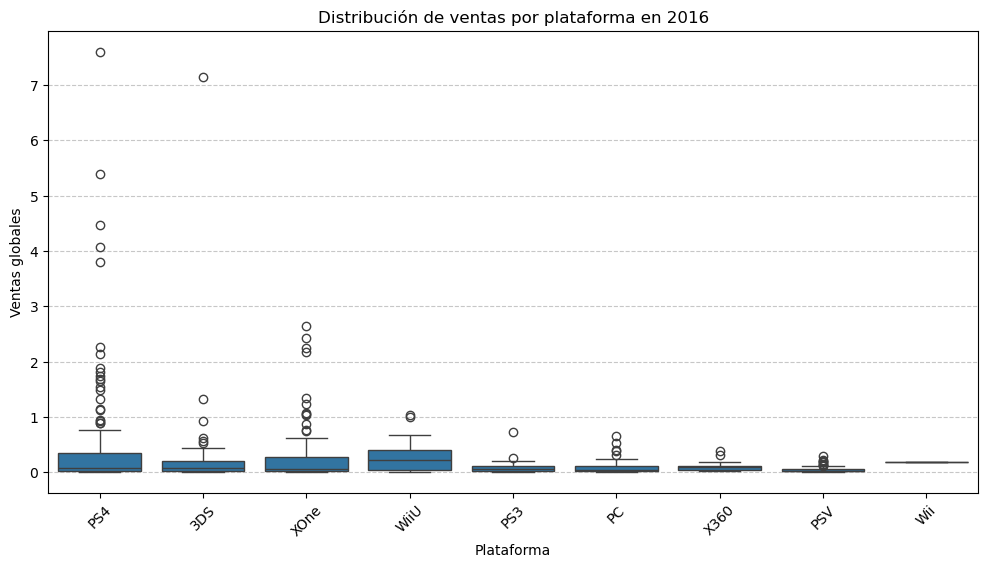

In [20]:
#Diagrama de caja
plt.figure(figsize=(12,6))
sns.boxplot(data=df_2016, x="platform", y="total_sales")

plt.xlabel("Plataforma")
plt.ylabel("Ventas globales")
plt.title("Distribución de ventas por plataforma en 2016")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Si hay plataformas con muchas ventas atípicas,eso podría indicar la presencia de títulos muy exitosos que elevan la media de ventas.

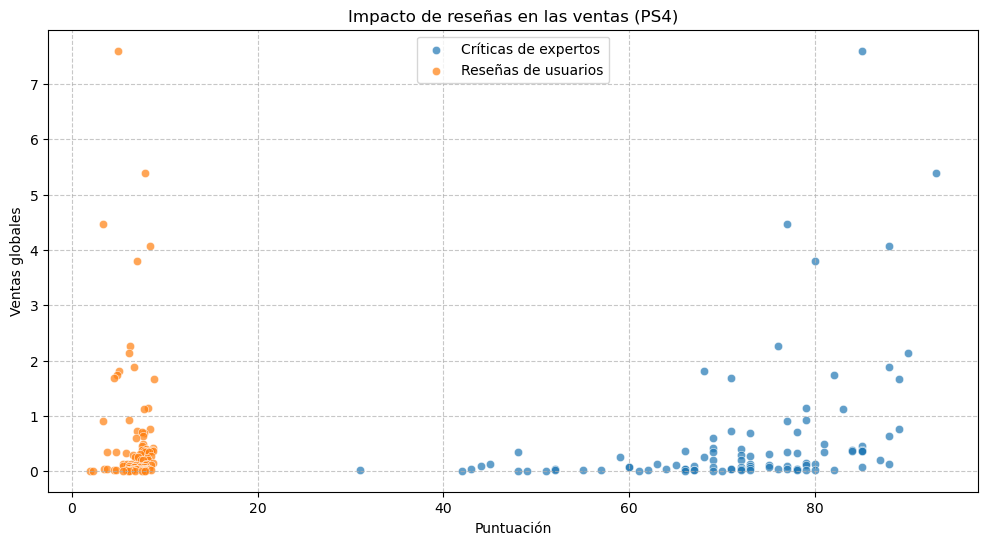

In [21]:
#Relacion entre reseñas y venta, en este caso, tomaremos como referencia el PS4
df_ps4=df_2016[df_2016["platform"]=="PS4"]
# Graficar la relación entre reseñas y ventas
plt.figure(figsize=(12,6))
sns.scatterplot(data=df_ps4, x="critic_score", y="total_sales", label="Críticas de expertos", alpha=0.7)
sns.scatterplot(data=df_ps4, x="user_score", y="total_sales", label="Reseñas de usuarios", alpha=0.7)
plt.xlabel("Puntuación")
plt.ylabel("Ventas globales")
plt.title("Impacto de reseñas en las ventas (PS4)")
plt.legend()
plt.grid(axis="both", linestyle="--", alpha=0.7)
plt.show()

In [22]:
#Calculo de correlación
print("Correlación crítica-ventas:", df_ps4["critic_score"].corr(df_ps4["total_sales"]))
print("Correlación usuarios-ventas:", df_ps4["user_score"].corr(df_ps4["total_sales"]))

Correlación crítica-ventas: 0.37569493421469646
Correlación usuarios-ventas: -0.122461124196492


Con esta información se evidencia que la puntuación de los críticos está un poco más relacionada con las ventas que la de los usuarios, aunque la correlación es débil. En User_Score no hay una tendencia clara, pero en Critic_Score, los juegos mejor calificados tienden a vender más. Esto sugiere que las críticas especializadas pueden tener mayor impacto en las ventas.

In [23]:
#Comparación de juegos multiplataformas
ventas_por_juego = df_2016.groupby(["name", "platform"])["total_sales"].sum().reset_index() # Agrupar datos por nombre de juego y plataforma
juegos_multiplataforma = ventas_por_juego[ventas_por_juego["name"].duplicated(keep=False)]# Ver ejemplos de juegos con ventas en múltiples plataformas
print(juegos_multiplataforma.head(10))

                                  name platform  total_sales
4                        7 Days to Die      PS4         0.14
5                        7 Days to Die     XOne         0.05
8   Aegis of Earth: Protonovus Assault      PS3         0.02
9   Aegis of Earth: Protonovus Assault      PS4         0.02
10  Aegis of Earth: Protonovus Assault      PSV         0.03
11   Agatha Christie's The ABC Murders      PS4         0.02
12   Agatha Christie's The ABC Murders     XOne         0.01
19         Assassin's Creed Chronicles      PS4         0.08
20         Assassin's Creed Chronicles      PSV         0.07
21         Assassin's Creed Chronicles     XOne         0.01


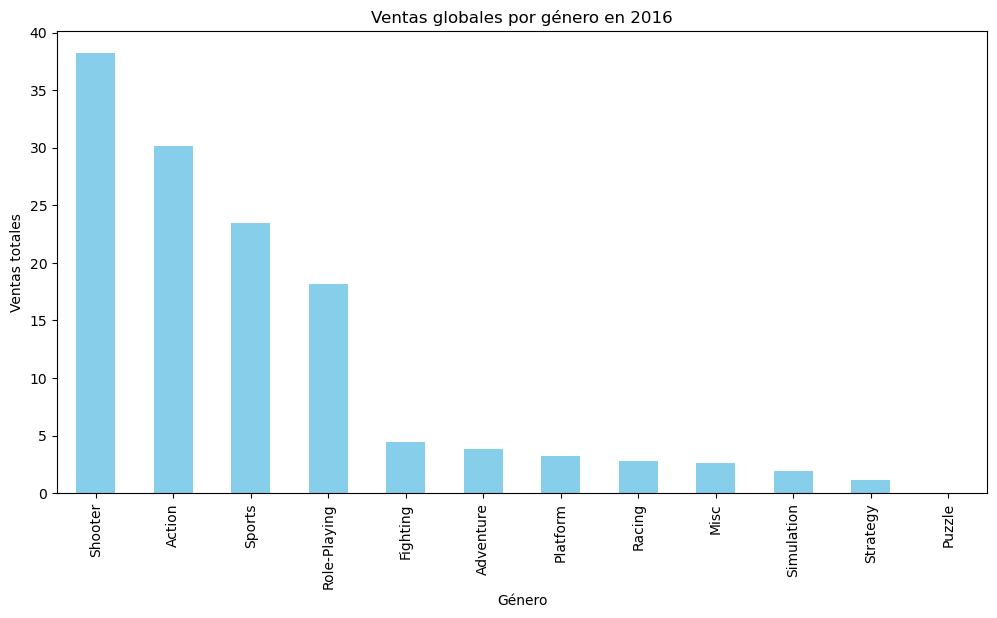

In [24]:
#Distribucion de ventas por genero
# Calcular ventas totales por género
ventas_por_genero = df_2016.groupby("genre")["total_sales"].sum().sort_values(ascending=False)
# Graficar en barras
ventas_por_genero.plot(
    kind="bar",
    title="Ventas globales por género en 2016",
    xlabel="Género",
    ylabel="Ventas totales",
    legend=False,
    color="skyblue",
    figsize=(12,6)
)

plt.show()

Basado en estos análisis, podríamos decir:
- Los géneros de acción, disparos y deportes suelen generar más ingresos, ya que tienen una gran base de jugadores y títulos populares.
- Los géneros como estrategia, rompecabezas o simulación tienden a vender menos, pues están dirigidos a audiencias más específicas.
- Un género con muchos juegos no siempre es el más rentable, porque la cantidad de títulos no garantiza grandes ventas.


In [25]:
#PLATAFORMAS QUE DOMINAN EL MERCADO 
# Calcular ventas por plataforma en cada región
ventas_por_plataforma_region = df_2016.groupby("platform")[["na_sales", "eu_sales", "jp_sales"]].sum()
# Identificar las cinco principales plataformas en cada región
top_plataformas_na = ventas_por_plataforma_region["na_sales"].sort_values(ascending=False).head(5)
top_plataformas_eu = ventas_por_plataforma_region["eu_sales"].sort_values(ascending=False).head(5)
top_plataformas_jp = ventas_por_plataforma_region["jp_sales"].sort_values(ascending=False).head(5)
print("Top 5 plataformas en NA:\n", top_plataformas_na)
print()
print("Top 5 plataformas en UE:\n", top_plataformas_eu)
print()
print("Top 5 plataformas en JP:\n", top_plataformas_jp)
print()

Top 5 plataformas en NA:
 platform
PS4     21.49
XOne    14.27
3DS      4.14
WiiU     2.10
PC       1.36
Name: na_sales, dtype: float64

Top 5 plataformas en UE:
 platform
PS4     31.78
XOne     9.63
PC       3.53
3DS      2.33
WiiU     1.48
Name: eu_sales, dtype: float64

Top 5 plataformas en JP:
 platform
3DS     8.03
PS4     5.74
PSV     3.56
PS3     1.30
WiiU    0.67
Name: jp_sales, dtype: float64



In [26]:
##IDENTIFICACIÓN DE CADA GENERO DOMINANTE POR REGIÓN
# Calcular ventas por género en cada región
ventas_por_genero_region = df_2016.groupby("genre")[["na_sales", "eu_sales", "jp_sales"]].sum()
# Identificar los cinco principales géneros por región
top_generos_na = ventas_por_genero_region["na_sales"].sort_values(ascending=False).head(5)
top_generos_eu = ventas_por_genero_region["eu_sales"].sort_values(ascending=False).head(5)
top_generos_jp = ventas_por_genero_region["jp_sales"].sort_values(ascending=False).head(5)
print("Top 5 géneros en NA:\n", top_generos_na)
print()
print("Top 5 géneros en UE:\n", top_generos_eu)
print()
print("Top 5 géneros en JP:\n", top_generos_jp)
print()

Top 5 géneros en NA:
 genre
Shooter         16.24
Action           9.29
Sports           7.54
Role-Playing     5.89
Fighting         1.84
Name: na_sales, dtype: float64

Top 5 géneros en UE:
 genre
Shooter         15.90
Sports          12.01
Action          10.68
Role-Playing     4.28
Racing           1.77
Name: eu_sales, dtype: float64

Top 5 géneros en JP:
 genre
Action          7.07
Role-Playing    6.61
Adventure       1.18
Shooter         1.06
Misc            1.04
Name: jp_sales, dtype: float64



In [27]:
#AFECTACIÓN DE LA ESRB POR REGIÓN
# Calcular ventas por clasificación ESRB en cada región
ventas_por_rating_region = df_2016.groupby("rating")[["na_sales", "eu_sales", "jp_sales"]].sum()
print("Ventas por clasificación ESRB en NA:\n", ventas_por_rating_region["na_sales"])
print()
print("Ventas por clasificación ESRB en UE:\n", ventas_por_rating_region["eu_sales"])
print()
print("Ventas por clasificación ESRB en JP:\n", ventas_por_rating_region["jp_sales"])

Ventas por clasificación ESRB en NA:
 rating
E        7.97
E10+     3.81
M       15.67
T        8.95
Name: na_sales, dtype: float64

Ventas por clasificación ESRB en UE:
 rating
E       13.61
E10+     3.81
M       16.54
T        9.79
Name: eu_sales, dtype: float64

Ventas por clasificación ESRB en JP:
 rating
E       1.07
E10+    0.45
M       1.20
T       2.27
Name: jp_sales, dtype: float64


Conclusiones
- Las plataformas dominantes cambian según la región: PlayStation y Xbox en occidente, Nintendo y handhelds en Japón.
- Los géneros más vendidos reflejan diferencias culturales: Acción y disparos en occidente, RPGs y peleas en Japón.
- La clasificación ESRB puede afectar las ventas, pero su impacto varía según la región y el sistema de clasificación local.

Prueba de hipotesis

In [29]:
#Comparación de calificaciones de Xbox One y PC
# Filtrar datos para cada plataforma
xbox_one_scores = df_2016[df_2016["platform"] == "XOne"]["user_score"].dropna()
pc_scores = df_2016[df_2016["platform"] == "PC"]["user_score"].dropna()
# Realizar la prueba t de Student
alpha = 0.05  # Umbral de significancia
t_stat, p_value = ttest_ind(xbox_one_scores, pc_scores, equal_var=False)
# Evaluar resultados
print(f"Estadístico t: {t_stat:.4f}, Valor p: {p_value:.4f}")
if p_value < alpha:
    print("Rechazamos la hipótesis nula: Las calificaciones promedio son diferentes.")
else:
    print("No hay suficiente evidencia para rechazar la hipótesis nula: Las calificaciones promedio podrían ser iguales.")

Estadístico t: 0.9365, Valor p: 0.3516
No hay suficiente evidencia para rechazar la hipótesis nula: Las calificaciones promedio podrían ser iguales.


In [30]:
#Comparacion de calificaciones de generos de acción y deportes
# Filtrar datos para cada género
accion_scores = df_2016[df_2016["genre"] == "Action"]["user_score"].dropna()
deportes_scores = df_2016[df_2016["genre"] == "Sports"]["user_score"].dropna()
# Realizar la prueba t de Student
t_stat, p_value = ttest_ind(accion_scores, deportes_scores, equal_var=False)
# Evaluar resultados
print(f"Estadístico t: {t_stat:.4f}, Valor p: {p_value:.4f}")
if p_value < alpha:
    print("Rechazamos la hipótesis nula: Las calificaciones promedio son diferentes.")
else:
    print("No hay suficiente evidencia para rechazar la hipótesis nula: Las calificaciones promedio podrían ser iguales.")

Estadístico t: 3.2470, Valor p: 0.0020
Rechazamos la hipótesis nula: Las calificaciones promedio son diferentes.


- Criterio de prueba elegido
- Prueba t de Student: Permite comparar si las diferencias en los promedios son estadísticamente significativas.
- Prueba de Welch (equal_var=False): Es más robusta si las varianzas de los dos grupos son diferentes.
- Umbral alfa = 0.05: Si p-value < 0.05, hay una diferencia significativa con 95% de confianza.

# Conclusión General

Análisis y hallazgos principales

Tras explorar el conjunto de datos de ventas de videojuegos, podemos extraer las siguientes conclusiones clave:

1. Tendencias de ventas por plataforma 
   - Las plataformas con mayores ventas globales en 2016 fueron PlayStation 4 y Xbox One en occidente, mientras que Nintendo 3DS tuvo una fuerte presencia en Japón.  
   - Algunas plataformas han declinado en ventas, mientras que otras continúan expandiéndose.  
   - Las plataformas nuevas suelen tardar varios años en ganar tracción antes de alcanzar su pico de ventas.

2. Impacto de los géneros en ventas
   - Los géneros Action, Shooter y Sports dominaron en ventas globales.  
   - En Japón, los RPGs y Fighting games tuvieron más éxito en comparación con occidente.  
   - Aunque algunos géneros tienen más juegos publicados, no siempre son los más rentables.  

3. Influencia de las reseñas en las ventas
   - Se observó una correlación positiva entre la puntuación de los críticos y las ventas, indicando que juegos bien evaluados tienden a vender más.  
   - Las reseñas de usuarios tienen un impacto menor en las ventas en comparación con las de críticos.  

4. Distribución regional de ventas  
   - Norteamérica y Europa muestran similitudes en plataformas y géneros populares.  
   - Japón tiene una fuerte preferencia por juegos de Nintendo y RPGs.  
   - Las clasificaciones ESRB afectan más a las ventas en NA y EU que en Japón, donde se usa un sistema distinto.  